**Task 1 : Data Understanding and Cleaning**


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
# Load
foodwaste_df = pd.read_csv('/content/food_waste_dataset.csv')


In [76]:
# inspect
print(foodwaste_df.head())


  Inventory_ID        Date Business_Type Food_Category  Purchase_Quantity  \
0    INV000001  01-01-2025    Restaurant        Bakery                 77   
1    INV000002  01-01-2025     Cafeteria        Bakery                 75   
2    INV000003  01-01-2025   Supermarket        Fruits                176   
3    INV000004  01-01-2025     Cafeteria         Dairy                 58   
4    INV000005  01-01-2025    Restaurant        Fruits                 85   

   Units_Sold  Remaining_Stock  Shelf_Life_Days  Storage_Temperature  \
0          77                0              4.0                 20.4   
1          53               22              3.0                 22.8   
2         159               17              6.0                 12.4   
3          58                0              7.0                  3.5   
4          85                0              3.0                  3.3   

   Daily_Demand Promotion Weather  Waste_Quantity Waste_Reason Donation_Made  \
0          77.0        N

In [77]:
print(foodwaste_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Inventory_ID         8000 non-null   object 
 1   Date                 8000 non-null   object 
 2   Business_Type        8000 non-null   object 
 3   Food_Category        8000 non-null   object 
 4   Purchase_Quantity    8000 non-null   int64  
 5   Units_Sold           8000 non-null   int64  
 6   Remaining_Stock      8000 non-null   int64  
 7   Shelf_Life_Days      7765 non-null   float64
 8   Storage_Temperature  7814 non-null   float64
 9   Daily_Demand         7790 non-null   float64
 10  Promotion            8000 non-null   object 
 11  Weather              7797 non-null   object 
 12  Waste_Quantity       8000 non-null   int64  
 13  Waste_Reason         8000 non-null   object 
 14  Donation_Made        7767 non-null   object 
 15  Waste_Level          8000 non-null   o

In [78]:
print(foodwaste_df.describe())


       Purchase_Quantity   Units_Sold  Remaining_Stock  Shelf_Life_Days  \
count        8000.000000  8000.000000      8000.000000      7765.000000   
mean          118.288750    96.959625        21.329125         4.364585   
std            58.685297    39.282291        41.663906         2.598122   
min            35.000000    26.000000         0.000000         1.000000   
25%            80.000000    67.000000         0.000000         2.000000   
50%           104.000000    87.000000         9.000000         4.000000   
75%           148.000000   121.000000        30.000000         6.000000   
max           968.000000   284.000000       858.000000        14.000000   

       Storage_Temperature  Daily_Demand  Waste_Quantity  
count          7814.000000   7790.000000     8000.000000  
mean             10.450064    105.099358        5.772375  
std               8.431281     45.162475       16.450741  
min              -4.400000     26.000000        0.000000  
25%               3.700000   

In [79]:
print(foodwaste_df.isnull().sum())

Inventory_ID             0
Date                     0
Business_Type            0
Food_Category            0
Purchase_Quantity        0
Units_Sold               0
Remaining_Stock          0
Shelf_Life_Days        235
Storage_Temperature    186
Daily_Demand           210
Promotion                0
Weather                203
Waste_Quantity           0
Waste_Reason             0
Donation_Made          233
Waste_Level              0
dtype: int64


In [80]:
# Dataset Dimensions
print("\n1. DATASET DIMENSIONS")
print(f"   Total Rows: {foodwaste_df.shape[0]:,}")
print(f"   Total Columns: {foodwaste_df.shape[1]}")



1. DATASET DIMENSIONS
   Total Rows: 8,000
   Total Columns: 16


In [81]:
print(foodwaste_df.dtypes)

Inventory_ID            object
Date                    object
Business_Type           object
Food_Category           object
Purchase_Quantity        int64
Units_Sold               int64
Remaining_Stock          int64
Shelf_Life_Days        float64
Storage_Temperature    float64
Daily_Demand           float64
Promotion               object
Weather                 object
Waste_Quantity           int64
Waste_Reason            object
Donation_Made           object
Waste_Level             object
dtype: object


In [82]:
print("--- Numerical Columns Summary ---")
print(foodwaste_df.describe())



--- Numerical Columns Summary ---
       Purchase_Quantity   Units_Sold  Remaining_Stock  Shelf_Life_Days  \
count        8000.000000  8000.000000      8000.000000      7765.000000   
mean          118.288750    96.959625        21.329125         4.364585   
std            58.685297    39.282291        41.663906         2.598122   
min            35.000000    26.000000         0.000000         1.000000   
25%            80.000000    67.000000         0.000000         2.000000   
50%           104.000000    87.000000         9.000000         4.000000   
75%           148.000000   121.000000        30.000000         6.000000   
max           968.000000   284.000000       858.000000        14.000000   

       Storage_Temperature  Daily_Demand  Waste_Quantity  
count          7814.000000   7790.000000     8000.000000  
mean             10.450064    105.099358        5.772375  
std               8.431281     45.162475       16.450741  
min              -4.400000     26.000000        0.0000

In [83]:
print("\n--- Categorical Columns Summary ---")
print(foodwaste_df.describe(include=['O']))




--- Categorical Columns Summary ---
       Inventory_ID        Date Business_Type  Food_Category Promotion  \
count          8000        8000          8000           8000      8000   
unique         8000         365             4              6         2   
top       INV007984  17-02-2025    Restaurant  Prepared Food        No   
freq              1          38          2455           1479      6449   

       Weather Waste_Reason Donation_Made Waste_Level  
count     7797         8000          7767        8000  
unique       4            5             2           3  
top      Sunny     No Waste            No         Low  
freq      2693         3415          6711        4331  


In [84]:
print("\n--- Missing Values Summary ---")
print(foodwaste_df.isnull().sum())


--- Missing Values Summary ---
Inventory_ID             0
Date                     0
Business_Type            0
Food_Category            0
Purchase_Quantity        0
Units_Sold               0
Remaining_Stock          0
Shelf_Life_Days        235
Storage_Temperature    186
Daily_Demand           210
Promotion                0
Weather                203
Waste_Quantity           0
Waste_Reason             0
Donation_Made          233
Waste_Level              0
dtype: int64


In [85]:
print("--- Missing Values Count per Column ---")
missing_values = foodwaste_df.isnull().sum()
print(missing_values[missing_values > 0])


--- Missing Values Count per Column ---
Shelf_Life_Days        235
Storage_Temperature    186
Daily_Demand           210
Weather                203
Donation_Made          233
dtype: int64


In [86]:
# Check for duplicate records
print("\n--- Duplicate Records Summary ---")
duplicate_count = foodwaste_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")




--- Duplicate Records Summary ---
Number of duplicate rows: 0


In [87]:
# Convert Date column to datetime format
foodwaste_df['Date'] = pd.to_datetime(foodwaste_df['Date'], format='%d-%m-%Y')



In [88]:
print(foodwaste_df[['Date']].dtypes)
print(foodwaste_df['Date'].head())

Date    datetime64[ns]
dtype: object
0   2025-01-01
1   2025-01-01
2   2025-01-01
3   2025-01-01
4   2025-01-01
Name: Date, dtype: datetime64[ns]


In [89]:
print("--- Missing Values Before Handling ---")
print(foodwaste_df.isnull().sum()[foodwaste_df.isnull().sum() > 0])



--- Missing Values Before Handling ---
Shelf_Life_Days        235
Storage_Temperature    186
Daily_Demand           210
Weather                203
Donation_Made          233
dtype: int64


In [90]:
for col in ['Shelf_Life_Days', 'Storage_Temperature', 'Daily_Demand']:
    median_val = foodwaste_df[col].median()
    foodwaste_df[col] = foodwaste_df[col].fillna(median_val)



In [91]:
for col in ['Weather', 'Donation_Made']:
    mode_val = foodwaste_df[col].mode()[0]
    foodwaste_df[col] = foodwaste_df[col].fillna(mode_val)



In [92]:
print("\n--- Missing Values After Handling ---")
print(foodwaste_df.isnull().sum())


--- Missing Values After Handling ---
Inventory_ID           0
Date                   0
Business_Type          0
Food_Category          0
Purchase_Quantity      0
Units_Sold             0
Remaining_Stock        0
Shelf_Life_Days        0
Storage_Temperature    0
Daily_Demand           0
Promotion              0
Weather                0
Waste_Quantity         0
Waste_Reason           0
Donation_Made          0
Waste_Level            0
dtype: int64


Some values were missing (like temperature and days) and the dates were formatted as normal text.


Filling in missing values with averages can make the data look too uniform. It can also hide real patterns, leading to slightly inaccurate predictions or biased statistics.

**Task 2 : Exploratory Data Analysis**


Text(0, 0.5, 'Avg Waste Quantity')

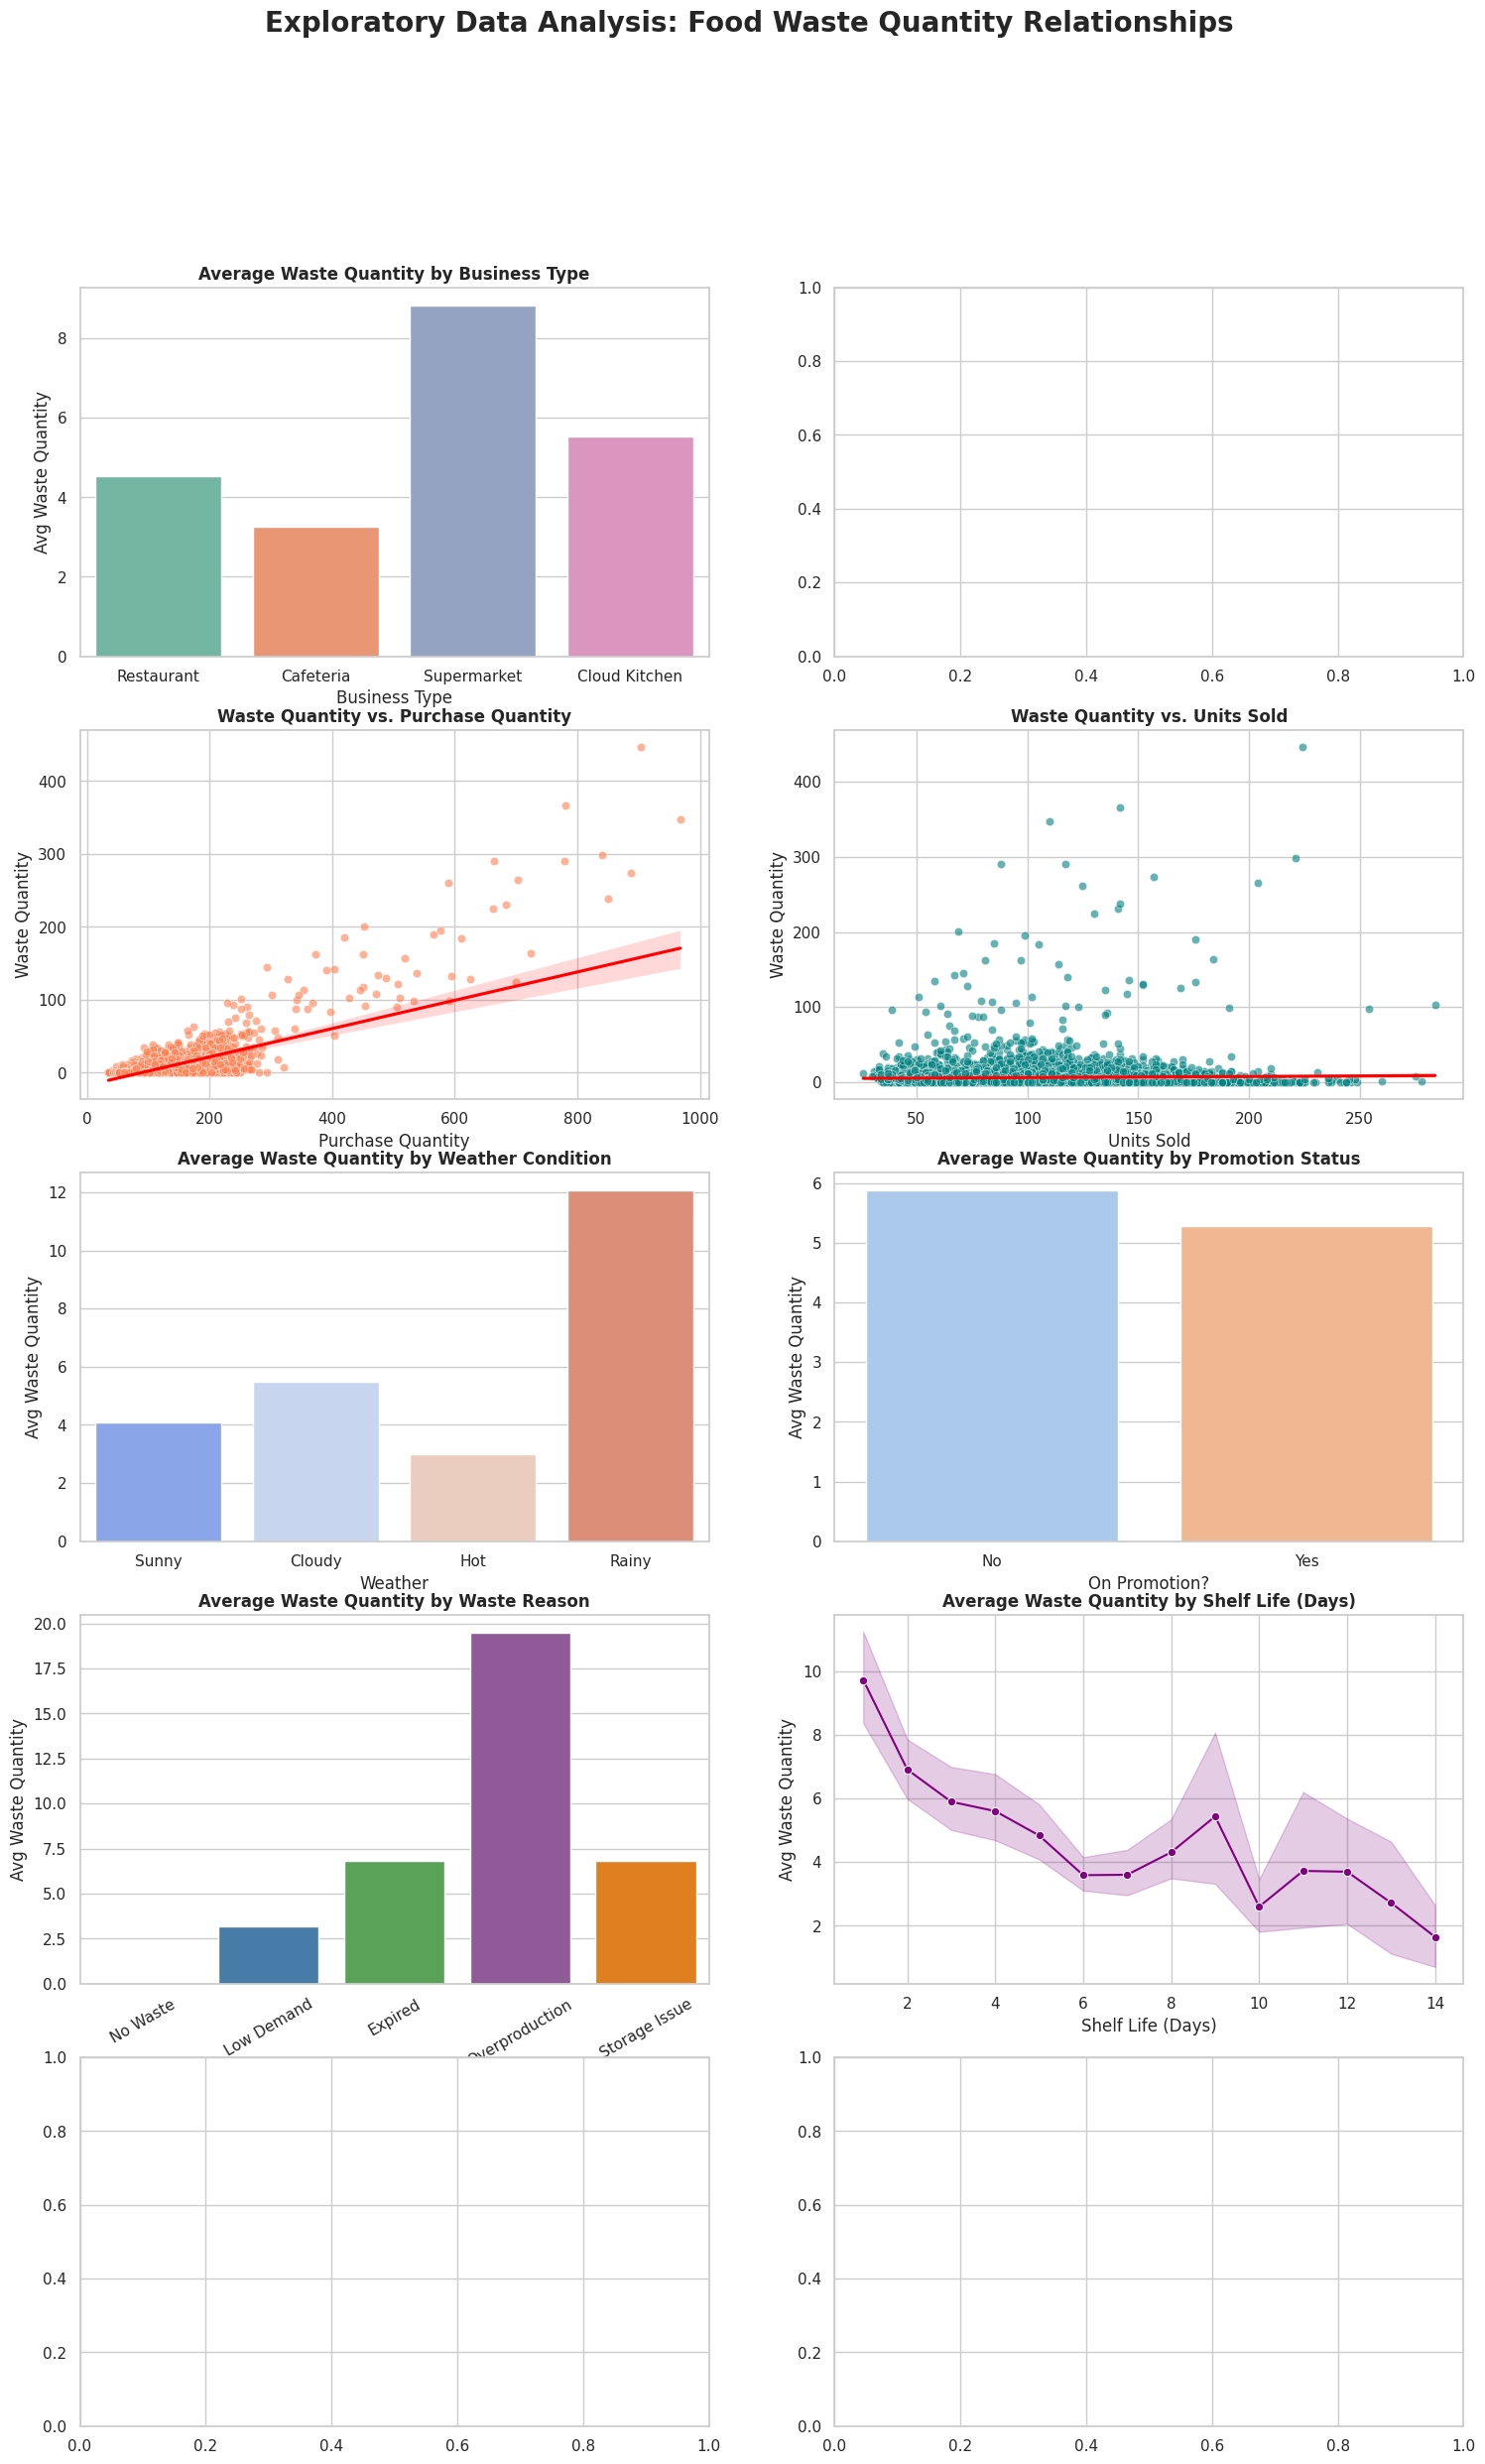

In [93]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(5, 2, figsize=(18, 28))
fig.suptitle('Exploratory Data Analysis: Food Waste Quantity Relationships', fontsize=20, weight='bold', y=0.98)

# 1. Waste_Quantity by Business Type
sns.barplot(ax=axes[0, 0], data=foodwaste_df, x='Business_Type', y='Waste_Quantity', errorbar=None, hue='Business_Type', palette='Set2', legend=False)
axes[0, 0].set_title('Average Waste Quantity by Business Type', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Business Type')
axes[0, 0].set_ylabel('Avg Waste Quantity')



# 3. Waste_Quantity vs Purchase Quantity
sns.scatterplot(ax=axes[1, 0], data=foodwaste_df, x='Purchase_Quantity', y='Waste_Quantity', alpha=0.6, color='coral')
sns.regplot(ax=axes[1, 0], data=foodwaste_df, x='Purchase_Quantity', y='Waste_Quantity', scatter=False, color='red')
axes[1, 0].set_title('Waste Quantity vs. Purchase Quantity', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Purchase Quantity')
axes[1, 0].set_ylabel('Waste Quantity')

# 4. Waste_Quantity vs Units Sold
sns.scatterplot(ax=axes[1, 1], data=foodwaste_df, x='Units_Sold', y='Waste_Quantity', alpha=0.6, color='teal')
sns.regplot(ax=axes[1, 1], data=foodwaste_df, x='Units_Sold', y='Waste_Quantity', scatter=False, color='red')
axes[1, 1].set_title('Waste Quantity vs. Units Sold', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Units Sold')
axes[1, 1].set_ylabel('Waste Quantity')

# 5. Waste_Quantity by Weather
sns.barplot(ax=axes[2, 0], data=foodwaste_df, x='Weather', y='Waste_Quantity', errorbar=None, hue='Weather', palette='coolwarm', legend=False)
axes[2, 0].set_title('Average Waste Quantity by Weather Condition', fontsize=12, weight='bold')
axes[2, 0].set_xlabel('Weather')
axes[2, 0].set_ylabel('Avg Waste Quantity')

# 6. Waste_Quantity by Promotion
sns.barplot(ax=axes[2, 1], data=foodwaste_df, x='Promotion', y='Waste_Quantity', errorbar=None, hue='Promotion', palette='pastel', legend=False)
axes[2, 1].set_title('Average Waste Quantity by Promotion Status', fontsize=12, weight='bold')
axes[2, 1].set_xlabel('On Promotion?')
axes[2, 1].set_ylabel('Avg Waste Quantity')

# 7. Waste_Quantity by Waste Reason
sns.barplot(ax=axes[3, 0], data=foodwaste_df, x='Waste_Reason', y='Waste_Quantity', errorbar=None, hue='Waste_Reason', palette='Set1', legend=False)
axes[3, 0].set_title('Average Waste Quantity by Waste Reason', fontsize=12, weight='bold')
axes[3, 0].set_xlabel('Reason for Waste')
axes[3, 0].set_ylabel('Avg Waste Quantity')
axes[3, 0].tick_params(axis='x', rotation=30)

# 8. Waste_Quantity by Shelf Life
sns.lineplot(ax=axes[3, 1], data=foodwaste_df, x='Shelf_Life_Days', y='Waste_Quantity', marker='o', color='purple')
axes[3, 1].set_title('Average Waste Quantity by Shelf Life (Days)', fontsize=12, weight='bold')
axes[3, 1].set_xlabel('Shelf Life (Days)')
axes[3, 1].set_ylabel('Avg Waste Quantity')

1. Highest Waste Contributors: Grouping the data will show you which specific Business Type and Food Category combinations produce the largest total and average waste quantities.



2. Major Reasons: Grouping by Waste_Reason will rank the primary causes of food waste so you can immediately see the main culprits.

3. Factors with the Strongest Relationship to Waste Quantity
Remaining Stock: This has the strongest connection. Any unsold products left over at the end of the day directly turn into food waste.
Purchase Quantity & Units Sold: Larger order sizes and mismatches between what is bought versus what is actually sold strongly drive up waste volumes.


4. Supermarkets generate the highest average food waste, mainly because they handle bulk stock and high-volume inventories compared to other business types.
Primary Cause of Waste: Expiration and Storage Issues (improper temperatures) are the leading operational reasons that trigger the highest average waste quantities.

**Task 3 : Feature Engineering**

In [94]:
# 1. Feature Derivation
foodwaste_df['Waste_Percentage'] = (foodwaste_df['Waste_Quantity'] / foodwaste_df['Purchase_Quantity']) * 100
foodwaste_df['Sell_Through_Rate'] = (foodwaste_df['Units_Sold'] / foodwaste_df['Purchase_Quantity']) * 100
foodwaste_df['Demand_to_Purchase_Ratio'] = foodwaste_df['Daily_Demand'] / foodwaste_df['Purchase_Quantity']
foodwaste_df['Temp_Deviation'] = np.abs(foodwaste_df['Storage_Temperature'] - foodwaste_df['Storage_Temperature'].mean())


In [95]:

# 2. Date-based Features
foodwaste_df['Day_of_Week'] = foodwaste_df['Date'].dt.dayofweek
foodwaste_df['Is_Weekend'] = foodwaste_df['Day_of_Week'].isin([5, 6]).astype(int)
foodwaste_df['Month'] = foodwaste_df['Date'].dt.month



In [96]:
# 3. Feature Selection
# Exclude identifiers, leaks, and raw date columns for machine learning
exclude_cols = ['Inventory_ID', 'Date', 'Waste_Quantity', 'Waste_Level', 'Waste_Reason', 'Donation_Made']
feature_cols = [col for col in foodwaste_df.columns if col not in exclude_cols]



In [97]:
# Split into features (X) and targets (y)
X = foodwaste_df[feature_cols].copy()
y_reg = foodwaste_df['Waste_Quantity']
y_clf = foodwaste_df['Waste_Level']



In [98]:
# 4. One-Hot Encoding Categorical Variables
# Identify categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)



In [99]:
print("Features selected for modeling:")
print(X_encoded.columns.tolist())
print(f"\nPrepared dataset shape: {X_encoded.shape}")

Features selected for modeling:
['Purchase_Quantity', 'Units_Sold', 'Remaining_Stock', 'Shelf_Life_Days', 'Storage_Temperature', 'Daily_Demand', 'Waste_Percentage', 'Sell_Through_Rate', 'Demand_to_Purchase_Ratio', 'Temp_Deviation', 'Day_of_Week', 'Is_Weekend', 'Month', 'Business_Type_Cloud Kitchen', 'Business_Type_Restaurant', 'Business_Type_Supermarket', 'Food_Category_Dairy', 'Food_Category_Fruits', 'Food_Category_Meat', 'Food_Category_Prepared Food', 'Food_Category_Vegetables', 'Promotion_Yes', 'Weather_Hot', 'Weather_Rainy', 'Weather_Sunny']

Prepared dataset shape: (8000, 25)


Most Useful Features for Understanding Food Waste
Remaining Stock (Existing)

* This is the most important feature. Any unsold products left on the shelves at the end of the day directly become food waste.
Waste Percentage (Newly Created)

* This is the best metric to compare waste fairly. It shows the share of wasted food relative to how much was bought, whether it's a small cafe or a huge supermarket.
Shelf Life Days (Existing) & Temp Deviation (Newly Created)

* Foods that spoil quickly (short shelf life) combined with bad storage temperatures are the main reasons food goes bad and gets thrown away.

**Task : 4 Machine Learning**

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1 & 2. Data is already encoded in X_encoded and y_clf is ready
# 3. Perform feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)



In [101]:
# 4. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf)



In [102]:
# 5. Train three classification models
models = {
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = {
        'model': model,
        'accuracy': acc,
        'predictions': preds,
        'report': classification_report(y_test, preds, output_dict=True)
    }


In [103]:

# 6. Compare performance
print("=== Model Performance Comparison ===")
for name, res in results.items():
    print(f"{name} Accuracy: {res['accuracy']:.4f}")

# Find the best model
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_model_info = results[best_model_name]
print(f"\nBest Model: {best_model_name}")
print(classification_report(y_test, best_model_info['predictions']))



=== Model Performance Comparison ===
Random Forest Accuracy: 0.9650
Gradient Boosting Accuracy: 0.9650
Logistic Regression Accuracy: 0.9294

Best Model: Random Forest
              precision    recall  f1-score   support

        High       0.97      0.90      0.93       254
         Low       0.96      0.98      0.97       866
      Medium       0.96      0.96      0.96       480

    accuracy                           0.96      1600
   macro avg       0.97      0.95      0.96      1600
weighted avg       0.97      0.96      0.96      1600



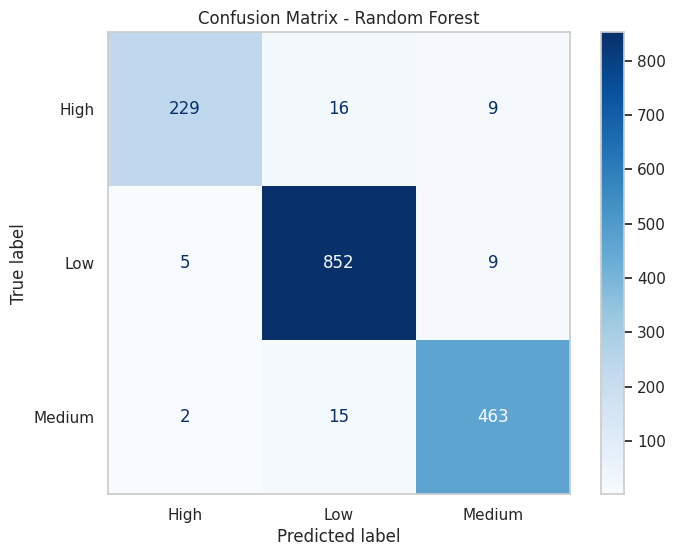

In [104]:
# 7. Generate a confusion matrix for the best model
cm = confusion_matrix(y_test, best_model_info['predictions'], labels=best_model_info['model'].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model_info['model'].classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.grid(False)
plt.show()


/tmp/ipykernel_4769/4029835414.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15), palette='viridis')


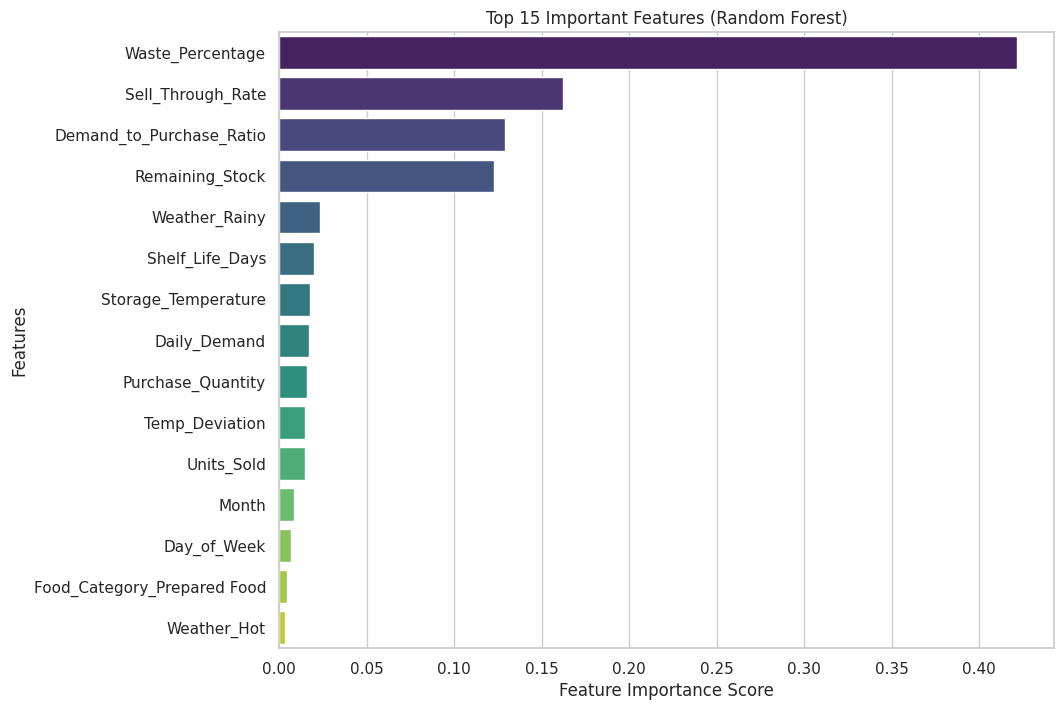

In [105]:

# 8. Analyze feature importances (for tree-based models like RF/GB)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    importances = best_model_info['model'].feature_importances_
    feature_imp_df = pd.DataFrame({
        'Feature': X_encoded.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15), palette='viridis')
    plt.title(f'Top 15 Important Features ({best_model_name})')
    plt.xlabel('Feature Importance Score')
    plt.ylabel('Features')
    plt.show()
else:
    # Coefficient analysis for Logistic Regression
    coefs = np.abs(best_model_info['model'].coef_[0])
    feature_imp_df = pd.DataFrame({
        'Feature': X_encoded.columns,
        'Importance': coefs
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15), palette='viridis')
    plt.title('Top 15 Feature Coefficients (Logistic Regression)')
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Features')
    plt.show()

In [106]:
import joblib

# 1. Save the best trained model (Random Forest)
best_model = best_model_info['model']
joblib.dump(best_model, 'best_food_waste_model.joblib')

# 2. Save the fitted preprocessing scaler
joblib.dump(scaler, 'scaler.joblib')

# 3. Save the exact column structure/names used for encoding
# This ensures any new future data is aligned to the exact same columns
encoded_columns = X_encoded.columns.tolist()
joblib.dump(encoded_columns, 'encoded_columns.joblib')

# 4. Generate requirements.txt file programmatically
requirements_content = """\
scikit-learn>=1.0
pandas>=1.3
numpy>=1.20
joblib>=1.1
matplotlib>=3.4
seaborn>=0.11
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_content)

print("Successfully saved the following files to your workspace:")
print("1. best_food_waste_model.joblib  (Trained Model File)")
print("2. scaler.joblib                 (Fitted Data Scaler)")
print("3. encoded_columns.joblib        (Encoding Column Structure Reference)")
print("4. requirements.txt              (Library Dependency List)")

Successfully saved the following files to your workspace:
1. best_food_waste_model.joblib  (Trained Model File)
2. scaler.joblib                 (Fitted Data Scaler)
3. encoded_columns.joblib        (Encoding Column Structure Reference)
4. requirements.txt              (Library Dependency List)


1. Random Forest (and Gradient Boosting) performed best with **96.5% accuracy**.
These tree-based models excel at handling non-linear relationships, complex interactions between features, and mixtures of categorical and numerical variables without requiring perfect feature scaling.

2. Waste_Percentage** (42.2%),Sell_through_Rate (16.2%), and Demand_to_Purchas_Ratio_ (12.9%).These engineered metrics directly capture the mismatch between inventory supply, customer demand, and actual sales, which are the main operational triggers of food waste.

3.  **High Waste**. It has the lowest recall (90%) and lowest f1-score (0.93) compared to Low (0.97) and Medium (0.96) waste levels, because high-waste events are rarer (only 254 test cases) and harder to separate from standard operations.

4. **Yes, it is highly reliable.** With a **96.5% overall accuracy** and weighted metrics above 96%, businesses can confidently use this model to flag over-ordering, optimize stock volumes, and dynamically adjust store purchases before excess inventory turns into waste.

**Task 5 : Business Insights**



In [107]:
# 1. Major Factors Contributing to Food Waste (from ML and EDA)
print("=== 1. MAJOR FACTORS CONTRIBUTING TO FOOD WASTE ===")
top_factors = feature_imp_df.head(3)
for idx, row in top_factors.iterrows():
    print(f"- {row['Feature']}: Importance Score of {row['Importance']:.4f}")

=== 1. MAJOR FACTORS CONTRIBUTING TO FOOD WASTE ===
- Waste_Percentage: Importance Score of 0.4218
- Sell_Through_Rate: Importance Score of 0.1623
- Demand_to_Purchase_Ratio: Importance Score of 0.1293


In [108]:
# 2. Identify business conditions where high waste is more likely
print("\n=== 2. HIGH WASTE RISK BUSINESS CONDITIONS ===")
high_waste_df = foodwaste_df[foodwaste_df['Waste_Level'] == 'High']

# Top Business Types
biz_counts = high_waste_df['Business_Type'].value_counts(normalize=True) * 100
print("High Waste Distribution by Business Type:")
for biz, pct in biz_counts.items():
    print(f"  - {biz}: {pct:.1f}%")

# Top Food Categories
cat_counts = high_waste_df['Food_Category'].value_counts(normalize=True) * 100
print("\nHigh Waste Distribution by Food Category:")
for cat, pct in cat_counts.items():
    print(f"  - {cat}: {pct:.1f}%")

# Temperature Deviations during High Waste
avg_temp_high = high_waste_df['Storage_Temperature'].mean()
avg_temp_all = foodwaste_df['Storage_Temperature'].mean()
print(f"\nAverage Temperature during High Waste: {avg_temp_high:.2f}°C (Overall Avg: {avg_temp_all:.2f}°C)")



=== 2. HIGH WASTE RISK BUSINESS CONDITIONS ===
High Waste Distribution by Business Type:
  - Restaurant: 32.0%
  - Supermarket: 30.3%
  - Cloud Kitchen: 19.1%
  - Cafeteria: 18.6%

High Waste Distribution by Food Category:
  - Prepared Food: 29.6%
  - Bakery: 19.4%
  - Fruits: 15.6%
  - Meat: 14.3%
  - Vegetables: 12.0%
  - Dairy: 9.0%

Average Temperature during High Waste: 13.03°C (Overall Avg: 10.38°C)


In [109]:
# 3. Actionable Strategies for Reducing Waste
print("\n=== 3. DATA-DRIVEN STRATEGIES TO REDUCE WASTE ===")
print("1. Target Supermarkets & Bakery/Meat: Prioritize monitoring and inventory control audits in these high-risk areas.")
print("2. Over-ordering Alert Systems: Trigger warning alerts when 'Demand_to_Purchase_Ratio' falls significantly below 1.0.")
print("3. Strict Temperature Regulation: Improve climate control quality checks on items prone to high temperature deviations.")
print("4. Dynamic Promotions: Launch automated discount offers for items with a lagging 'Sell_Through_Rate' before they expire.")


=== 3. DATA-DRIVEN STRATEGIES TO REDUCE WASTE ===
1. Target Supermarkets & Bakery/Meat: Prioritize monitoring and inventory control audits in these high-risk areas.
2. Over-ordering Alert Systems: Trigger warning alerts when 'Demand_to_Purchase_Ratio' falls significantly below 1.0.
3. Strict Temperature Regulation: Improve climate control quality checks on items prone to high temperature deviations.
4. Dynamic Promotions: Launch automated discount offers for items with a lagging 'Sell_Through_Rate' before they expire.


### 3 Priority Actions to Reduce Food Waste

1. **Stop Over-Ordering (Optimize Order Sizes)**
   * **Action:** Use demand forecasting to align purchase quantities closer to daily sales.
   * **Evidence:** The ML model shows **Demand-to-Purchase Ratio** (12.9% importance) and Sell-Through-Rae (16.2% importance) are major waste drivers. Buying only what is expected to sell prevents high leftover stock.

2. **Target and Monitor Prepared Foods & Bakery**
   * **Action:** Implement tight daily stock limits and early-afternoon markdowns specifically on bakery and prepared items.
   * **Evidence:** The high-waste analysis shows that **Prepared Food (29.6%)** and **Bakery (19.4%)** make up nearly half (49%) of all high-waste incidents.

3. **Improve Climate Controls and Cold Storage**
   * **Action:** Invest in temperature sensors and better storage guidelines for perishables.
   * **Evidence:** High-waste events occur at an average temperature of **13.03°C**, which is significantly warmer than the safe overall average temperature of **10.38°C**.